\title{}
\author{}
\date{}
\makeatletter
\renewcommand{\maketitle}{}
\makeatother

\thispagestyle{empty}

\begin{center}
\vspace*{4cm}

{\LARGE Asset Allocation \& Investment Strategies \\[0.5cm]}

Academic year: 2025--2026\\[1.5cm]

Group 8\\[0.3cm]
Sacha Mimoun\\
Isabelle Chuah\\
Victor Lotigie\\
Evelyn Wang\\
Bolun Tian\\[1.5cm]

\textit{Imperial College Business School}

\end{center}

\newpage

\setcounter{secnumdepth}{0}

\thispagestyle{empty}
\clearpage

\tableofcontents

\newpage

In [66]:
import pandas as pd
import numpy as np
import datetime
import os
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [3]:
# Import raw data

path = "raw_data/"
filename_factors = 'F-F_Research_Data_Factors.CSV'
filename_portfolios = '25_Portfolios_5x5.CSV'
filepath = os.path.join(path, filename_factors)
filepath_portfolios = os.path.join(path, filename_portfolios)

In [4]:
# Read F-F factors file - extract only monthly data
df_temp = pd.read_csv(filepath, skiprows=3, header=None)
separator_idx = df_temp[df_temp[0].astype(str).str.contains('Annual', case=False, na=False)].index[0]



In [55]:
# Read only monthly data (stop before annual section)
df_ff_monthly = pd.read_csv(filepath, skiprows=3, nrows=separator_idx-1)
# Clean monthly factors data
df_ff_monthly['date_str'] = df_ff_monthly.iloc[:, 0].astype(str).str.strip()
df_ff_monthly = df_ff_monthly[df_ff_monthly['date_str'].str.match(r'^\d{6}$')]
df_ff_monthly.index = pd.to_datetime(df_ff_monthly['date_str'], format='%Y%m').dt.strftime('%Y-%m-%d')

def to_num(df):
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

df_ff_monthly = to_num(df_ff_monthly)

df_ff_monthly = df_ff_monthly.iloc[:, 1:-1] / 100 # because it was in percentage before
print("Fama-French Monthly Factors:")
print(df_ff_monthly)
print(f"Shape: {df_ff_monthly.shape}")

Fama-French Monthly Factors:
            Mkt-RF     SMB     HML      RF
date_str                                  
1926-07-01  0.0296 -0.0256 -0.0243  0.0022
1926-08-01  0.0264 -0.0117  0.0382  0.0025
1926-09-01  0.0036 -0.0140  0.0013  0.0023
1926-10-01 -0.0324 -0.0009  0.0070  0.0032
1926-11-01  0.0253 -0.0010 -0.0051  0.0031
...            ...     ...     ...     ...
2023-08-01 -0.0239 -0.0316 -0.0106  0.0045
2023-09-01 -0.0524 -0.0251  0.0152  0.0043
2023-10-01 -0.0319 -0.0387  0.0019  0.0047
2023-11-01  0.0884 -0.0002  0.0164  0.0044
2023-12-01  0.0485  0.0635  0.0494  0.0043

[1170 rows x 4 columns]
Shape: (1170, 4)


Let's do the same for the 25 portfolios

In [6]:
# Read 25 Portfolios file - extract only monthly datasets
with open(filepath_portfolios, 'r') as f:
    lines = f.readlines()

# Find indices for monthly datasets
vw_idx = next(i for i, line in enumerate(lines) if 'Average Value Weighted Returns -- Monthly' in line)
ew_idx = next(i for i, line in enumerate(lines) if 'Average Equal Weighted Returns -- Monthly' in line)

print(f"VW Monthly: line {vw_idx}, EW Monthly: line {ew_idx}")

VW Monthly: line 14, EW Monthly: line 1188


In [59]:
# Extract monthly datasets
df_port_vw = pd.read_csv(filepath_portfolios, skiprows=vw_idx+1, nrows=ew_idx-vw_idx-3)
df_port_vw['Date'] = df_port_vw.iloc[:, 0].astype(str).str.strip()
df_port_vw = df_port_vw[df_port_vw['Date'].str.match(r'^\d{6}$', na=False)]
df_port_vw.index = pd.to_datetime(df_port_vw['Date'], format='%Y%m').dt.strftime('%Y-%m-%d')
df_port_vw = to_num(df_port_vw)

df_port_vw = df_port_vw.iloc[:, 1:-1] / 100

df_port_ew = pd.read_csv(filepath_portfolios, skiprows=ew_idx+1, nrows=ew_idx-vw_idx-3)
df_port_ew['Date'] = df_port_ew.iloc[:, 0].astype(str).str.strip()
df_port_ew = df_port_ew[df_port_ew['Date'].str.match(r'^\d{6}$', na=False)]
df_port_ew.index = pd.to_datetime(df_port_ew['Date'], format='%Y%m').dt.strftime('%Y-%m-%d')
df_port_ew = to_num(df_port_ew)
df_port_ew = df_port_ew.iloc[:, 1:-1] / 100 # it was again in percentage

print(f"\nVW Monthly: {df_port_vw.shape}")
print(df_port_vw)

print(f"EW Monthly: {df_port_ew.shape}")

#print(df_port_ew)


VW Monthly: (1170, 25)
            SMALL LoBM   ME1 BM2   ME1 BM3   ME1 BM4  SMALL HiBM   ME2 BM1  \
Date                                                                         
1926-07-01    0.058248 -0.017006  0.004875 -0.014580    0.020534  0.012077   
1926-08-01   -0.020206 -0.080282  0.013796  0.014606    0.083968  0.023618   
1926-09-01   -0.048291 -0.026154 -0.043417 -0.032729    0.008649 -0.026540   
1926-10-01   -0.093729 -0.035519 -0.034948  0.034413   -0.025476 -0.028069   
1926-11-01    0.055888  0.041877  0.024623 -0.044494    0.005362  0.031033   
...                ...       ...       ...       ...         ...       ...   
2023-08-01   -0.122376 -0.076627 -0.105103 -0.056405   -0.073431 -0.069345   
2023-09-01   -0.082275 -0.076201 -0.065856 -0.058185   -0.060216 -0.088904   
2023-10-01   -0.102240 -0.089443 -0.079196 -0.063774   -0.076783 -0.102040   
2023-11-01    0.057861  0.080737  0.107319  0.085040    0.070945  0.109883   
2023-12-01    0.153216  0.160383  0.1486

In [60]:
# Compute excess returns for the 25 portfolios
df_port_vw_excess = df_port_vw.sub(df_ff_monthly['RF'], axis=0)
df_port_ew_excess = df_port_ew.sub(df_ff_monthly['RF'], axis=0)

In [63]:
def slice_monthly(df, start, end):
    df.index = pd.to_datetime(df.index)
    start = pd.to_datetime(start)
    end = pd.to_datetime(end)
    return df.loc[(df.index >= start) & (df.index <= end)].copy()

start, end = "1964-01-01", "1993-01-01"

factors_6493 = slice_monthly(df_ff_monthly, start, end)
vw_port_excess_6493 = slice_monthly(df_port_vw_excess, start, end)

# BONUS : for equal-weighting
ew_port_excess_6493 = slice_monthly(df_port_ew_excess, start, end)

common_idx = factors_6493.index.intersection(vw_port_excess_6493.index)
factors_6493 = factors_6493.loc[common_idx]
ports_6493 = vw_port_excess_6493.loc[common_idx]

print("Sample range:", common_idx.min(), "→", common_idx.max())
print("T =", len(common_idx))
print("Aligned:", factors_6493.index.equals(ports_6493.index))

Sample range: 1964-01-01 00:00:00 → 1993-01-01 00:00:00
T = 349
Aligned: True


In [21]:
print(ports_6493)

            SMALL LoBM   ME1 BM2   ME1 BM3   ME1 BM4  SMALL HiBM   ME2 BM1  \
1964-01-01    0.036847  0.026078  0.039205  0.038486    0.045526 -0.023215   
1964-02-01    0.026988  0.025947  0.020073  0.000296    0.041942  0.013574   
1964-03-01    0.001930  0.011981  0.018931  0.032385    0.025121  0.020333   
1964-04-01   -0.018527  0.022981 -0.007426 -0.011988   -0.012124 -0.011990   
1964-05-01   -0.015118 -0.015745  0.002791  0.000878    0.011697  0.028853   
...                ...       ...       ...       ...         ...       ...   
1992-09-01    0.002120  0.012340  0.015981  0.019947    0.008409  0.012908   
1992-10-01    0.023034  0.017113  0.023651  0.017618    0.013572  0.045488   
1992-11-01    0.104459  0.106869  0.079416  0.080027    0.076541  0.090628   
1992-12-01    0.012935  0.028679  0.047902  0.041556    0.047862  0.012840   
1993-01-01    0.023874  0.052866  0.040558  0.043602    0.077916 -0.010212   

             ME2 BM2   ME2 BM3   ME2 BM4   ME2 BM5  ...   ME4 B

In [57]:
# Prepare results storage
results = []

mkt_rf = factors_6493['Mkt-RF']

def capm_regression(df_port):

    for col in df_port.columns:
        y = df_port[col]
        X = sm.add_constant(mkt_rf)
        model = sm.OLS(y, X).fit()
        
        results.append({
            'portfolio': col,
            "mean_excess": y.mean(),
            'alpha': model.params['const'],
            'beta': model.params['Mkt-RF'],
            'alpha_tstat': model.tvalues['const'],
            'beta_tstat': model.tvalues['Mkt-RF'],
            "adj_r2": model.rsquared_adj
        })

    df_results = pd.DataFrame(results).set_index("portfolio")
    return df_results

df_results = capm_regression(ports_6493)
print("\n Regression Results :")
print(df_results.to_string(index=True))



 Regression Results :
            mean_excess     alpha      beta  alpha_tstat  beta_tstat    adj_r2
portfolio                                                                     
SMALL LoBM     0.003090 -0.002637  1.425884    -1.126317   27.798851  0.689224
ME1 BM2        0.007425  0.002403  1.250530     1.186556   28.182754  0.695076
ME1 BM3        0.007840  0.003186  1.158853     1.726040   28.657677  0.702122
ME1 BM4        0.009437  0.005112  1.077028     2.793956   26.867342  0.674418
SMALL HiBM     0.010844  0.006414  1.103020     3.081514   24.185137  0.626578
ME2 BM1        0.004047 -0.001689  1.428427    -0.962518   37.147215  0.798485
ME2 BM2        0.006582  0.001625  1.234521     1.079549   37.442397  0.801022
ME2 BM3        0.008828  0.004346  1.116015     3.037569   35.597026  0.784406
ME2 BM4        0.009565  0.005416  1.033107     3.991288   34.744860  0.776091
ME2 BM5        0.010755  0.006243  1.123314     3.663913   30.086892  0.722094
ME3 BM1        0.004491 -0.00

In [38]:
size_order = ["SMALL", "ME2", "ME3", "ME4", "BIG"]
size_names = ["Small", "2", "3", "4", "Big"]

bm_order = ["LoBM", "BM2", "BM3", "BM4", "HiBM"]
bm_names = ["Low", "2", "3", "4", "High"]

def parse_ff_portfolio_label(label: str):
    """
    Returns (size_bucket, bm_bucket) from labels like:
    - 'SMALL LoBM' -> ('SMALL', 'LoBM')
    - 'ME3 BM4' -> ('ME3', 'BM4')
    - 'BIG HiBM' -> ('BIG', 'HiBM')

    Note: ME rows use BM1/BM5 sometimes, which correspond to LoBM/HiBM.
    """
    parts = label.split()
    if len(parts) != 2:
        return None

    size, bm = parts[0], parts[1]

    if size not in {"SMALL", "ME1", "ME2", "ME3", "ME4", "ME5", "BIG"}:
        return None

    # Normalize size naming: treat ME1 as SMALL row, ME5 as BIG row (FF conventions)
    if size == "ME1":
        size = "SMALL"
    if size == "ME5":
        size = "BIG"

    # Normalize BM endpoints
    if bm == "BM1":
        bm = "LoBM"
    if bm == "BM5":
        bm = "HiBM"

    return size, bm

def to_5x5(res_df: pd.DataFrame, col: str) -> pd.DataFrame:
    tbl = pd.DataFrame(np.nan, index=size_names, columns=bm_names)

    for port in res_df.index:
        parsed = parse_ff_portfolio_label(port)
        if parsed is None:
            continue
        size, bm = parsed

        if (size in size_order) and (bm in bm_order):
            i = size_order.index(size)
            j = bm_order.index(bm)
            tbl.iloc[i, j] = res_df.loc[port, col]

    return tbl

tables_6493 = {
    "Mean excess return": to_5x5(df_results, "mean_excess"),
    "Beta (rmrf)": to_5x5(df_results, "beta"),
    "t(Beta)": to_5x5(df_results, "beta_tstat"),
    "Alpha": to_5x5(df_results, "alpha"),
    "t(Alpha)": to_5x5(df_results, "alpha_tstat"),
    "Adj R^2": to_5x5(df_results, "adj_r2"),
}


In [39]:
for name, tbl in tables_6493.items():
    print("\n" + name)
    display(tbl)


Mean excess return


,Low,2,3,4,High
Small,0.003090,0.007425,0.007840,0.009437,0.010844
2,0.004047,0.006582,0.008828,0.009565,0.010755
3,0.004491,0.006975,0.007049,0.008792,0.010202
4,0.004657,0.004035,0.006177,0.008066,0.009194
Big,0.003263,0.003467,0.003490,0.005139,0.006125



Beta (rmrf)


,Low,2,3,4,High
Small,1.425884,1.250530,1.158853,1.077028,1.103020
2,1.428427,1.234521,1.116015,1.033107,1.123314
3,1.353789,1.162876,1.033577,0.975694,1.069104
4,1.223638,1.128797,1.034855,0.973928,1.081046
Big,1.001999,0.982546,0.866932,0.834828,0.870462



t(Beta)


...

,Low,2,3,4,High
Small,-0.002637,0.002403,0.003186,0.005112,0.006414
2,-0.001689,0.001625,0.004346,0.005416,0.006243
3,-0.000945,0.002305,0.002898,0.004873,0.005908
4,-0.000257,-0.000498,0.002021,0.004155,0.004853
Big,-0.000761,-0.000479,0.000008,0.001786,0.002629



t(Alpha)


,Low,2,3,4,High
Small,-1.126317,1.186556,1.726040,2.793956,3.081514
2,-0.962518,1.079549,3.037569,3.991288,3.663913
3,-0.697838,1.981224,2.549935,4.272519,3.722447
4,-0.254490,-0.552534,2.130326,3.693725,3.305077
Big,-0.826358,-0.625438,0.008073,1.718931,1.760606



Adj R^2


,Low,2,3,4,High
Small,0.689224,0.695076,0.702122,0.674418,0.626578
2,0.798485,0.801022,0.784406,0.776091,0.722094
3,0.856597,0.856670,0.831826,0.814020,0.730655
4,0.897678,0.903559,0.876877,0.817672,0.764250
Big,0.876410,0.907838,0.821534,0.794213,0.670104


Table (i) reports the results of CAPM time-series regressions for the 25 Fama–French size–book-to-market portfolios over the period January 1964 to January 1993.

A clear pattern emerges in average excess returns. For a given size group, mean returns increase monotonically from low to high book-to-market portfolios. For example, among small stocks, the average monthly excess return rises from about 0.31% for low B/M portfolios to more than 1.08% for high B/M portfolios. A similar value pattern is present across all size categories, while the size effect itself is weaker and less systematic.

Estimated market betas are all positive and highly statistically significant, with t-statistics well above conventional thresholds. Betas tend to be higher for small portfolios and lower for large portfolios, indicating that smaller firms are more exposed to market risk. This pattern is broadly consistent with standard asset-pricing intuition.

Despite the strong explanatory power of the market factor, the CAPM alphas are not zero for many portfolios. Alphas are generally close to zero (and often slightly negative) for low book-to-market portfolios, but become positive and economically meaningful for high book-to-market portfolios. Several high B/M portfolios exhibit alphas that are statistically significant, suggesting systematic pricing errors under the CAPM.

Finally, adjusted R^2 values are relatively high, typically ranging from about 0.65 to above 0.90, indicating that the market factor explains a large share of the time-series variation in returns. However, the presence of significant alphas shows that a good fit in the time series does not imply correct pricing in the cross-section.

Overall, these results suggest that while the CAPM captures market exposure reasonably well, it fails to explain the cross-sectional variation in average returns, particularly the value premium observed across book-to-market portfolios.

## Question (ii)

Looking at the 5×5 table of mean monthly **excess** returns, the strongest pattern is clearly along the **book-to-market** dimension. As you move from **Low B/M to High B/M** (left -> right), average excess returns increase almost everywhere in the grid. For example, for small stocks the mean excess return goes from roughly **0.31% per month** (Low) to about **1.08% per month** (High). Even for big stocks the same direction holds, just with a smaller spread (around **0.33% -> 0.61%** per month).

Along the **size** dimension (top -> bottom), things are much less clean: returns don’t move in a perfectly monotonic way when you hold B/M fixed. So if we had to summarise it simply, average excess returns mostly rise **westward**, towards high book-to-market portfolios. Across all size groups, High B/M portfolios earn higher average excess returns than Low B/M portfolios, so the biggest systematic increase is along **book-to-market**, not size.

This naturally raises the question of whether CAPM betas move enough to explain this return spread.

# Question (iii)

From (ii), average excess returns vary a lot across the 5×5 grid, especially moving from
**Low B/M to High B/M**.

The CAPM would say: portfolios with higher average excess returns should simply have
higher exposure to the market factor, i.e. higher **β**. So the natural check is:

- do the portfolios with higher mean returns also have higher CAPM betas?
- in particular, does the **value spread** (High B/M − Low B/M) show up as a **beta spread**?

If mean returns move a lot but betas don’t move much (or don’t move in the right direction),
then the spread in average returns is a CAPM “puzzle”.

In [44]:
df_mean = tables_6493["Mean excess return"]
beta_tbl = tables_6493["Beta (rmrf)"]

hl_mean = (df_mean["High"] - df_mean["Low"]).rename("High-Low mean (monthly))")
hl_beta = (beta_tbl["High"] - beta_tbl["Low"]).rename("High-Low beta")

hl_check = pd.concat([hl_mean, hl_beta], axis=1)
display(hl_check)

print("Average High–Low mean spread (monthly)):", float(hl_mean.mean().round(4)))
print("Average High–Low beta spread:", float(hl_beta.mean().round(4)))

,High-Low mean (monthly)),High-Low beta
Small,0.007754,-0.322864
2,0.006707,-0.305113
3,0.005711,-0.284685
4,0.004537,-0.142592
Big,0.002861,-0.131536


Average High–Low mean spread (monthly)): 0.0055
Average High–Low beta spread: -0.2374


The spread in average excess returns across the 25 portfolios does represent a puzzle from the perspective of the CAPM.

From Question (ii), we observed a strong increase in average excess returns when moving from **Low to High book-to-market** portfolios. The High–Low return spread is economically large, averaging around **0.55% per month** across size groups.

However, this pattern is **not explained by market risk** as measured by the CAPM βs. Within each size category, High B/M portfolios tend to have **lower market betas** than Low B/M portfolios. The High–Low beta spread is negative for all size groups, with an average close to **−0.24**.

According to the CAPM, higher expected returns should be associated with higher market risk. Here, portfolios that earn higher average returns do not exhibit higher exposure to the market factor. In fact, the relationship goes in the opposite direction.

Therefore, the return spread itself is not the puzzle; the puzzle arises when we compare this spread to the pattern of CAPM βs. The CAPM fails to explain why High book-to-market portfolios earn higher average excess returns despite having lower market risk.

This failure of the CAPM to account for the systematic return differences across portfolios naturally raises the question of whether additional risk factors are needed to explain these patterns, which we investigate in the next question.

## Question (iv) 

This question is mostly about reading the CAPM regression outputs from (i).

What we want to check:
1) how many CAPM alphas are statistically significant (at 5% and 1%)
2) where they tend to show up in the 5×5 grid (e.g., value side vs growth side)
3) whether the adjusted R² values are generally high or low, and what that implies

We’ll keep the code minimal: just a couple of quick counts + a short summary table.

In [48]:
# We already have: capm_6493 (portfolio-level regression output)
# and tables_6493 (5×5 tables including t(Alpha) and Adj R^2)

alpha_t = df_results["alpha_tstat"].dropna()
n_5 = int((alpha_t.abs() >= 1.96).sum())
n_1 = int((alpha_t.abs() >= 2.58).sum())

print(f"Significant alphas at 5%  (|t|>=1.96): {n_5} / {len(alpha_t)}")
print(f"Significant alphas at 1%  (|t|>=2.58): {n_1} / {len(alpha_t)}")

# Show the most extreme alphas (by |t|)
top_alpha = df_results.loc[alpha_t.abs().sort_values(ascending=False).head(8).index,
                          ["alpha", "alpha_tstat", "beta", "adj_r2", "mean_excess"]].copy()

top_alpha["alpha_%"] = top_alpha["alpha"] * 100
top_alpha["mean_excess_%"] = top_alpha["mean_excess"] * 100

display(top_alpha[["mean_excess_%", "alpha_%", "alpha_tstat", "beta", "adj_r2"]].round(4))

Significant alphas at 5%  (|t|>=1.96): 12 / 25
Significant alphas at 1%  (|t|>=2.58): 9 / 25


,mean_excess_%,alpha_%,alpha_tstat,beta,adj_r2
portfolio,,,,,
ME3 BM4,0.8792,0.4873,4.2725,0.9757,0.8140
ME2 BM4,0.9565,0.5416,3.9913,1.0331,0.7761
ME3 BM5,1.0202,0.5908,3.7224,1.0691,0.7307
ME4 BM4,0.8066,0.4155,3.6937,0.9739,0.8177
ME2 BM5,1.0755,0.6243,3.6639,1.1233,0.7221
ME4 BM5,0.9194,0.4853,3.3051,1.0810,0.7643
SMALL HiBM,1.0844,0.6414,3.0815,1.1030,0.6266
ME2 BM3,0.8828,0.4346,3.0376,1.1160,0.7844


  A statistically significant CAPM alpha indicates a systematic pricing error: the portfolio earns average returns that are too high (positive α) or
  too low (negative α) relative to what the CAPM predicts, even after controlling for market risk (β). Essentially, significant alphas reveal
  portfolios where the single-factor CAPM fails to correctly explain returns.

  In our results, significant alphas are concentrated among high book-to-market (value) portfolios. This pattern directly reflects the empirical
  puzzle identified earlier: average returns increase strongly moving from low to high B/M portfolios, but CAPM betas do not increase
  correspondingly—in fact, they tend to decrease. Because the CAPM cannot explain this systematic return spread through market risk alone, it leaves
  structured pricing errors that manifest as statistically significant alphas on the value side of the grid.

In [50]:
# Quick look at the 5×5 t(Alpha) table and Adj R^2 table
print("t(Alpha)")
display(tables_6493["t(Alpha)"].round(3))

print("\nAdjusted R^2")
display(tables_6493["Adj R^2"].round(3))

# Optional: summarize the distribution of adjusted R^2
r2 = df_results["adj_r2"].dropna()
print("\nAdj R^2 summary:")
display(r2.describe().round(3))

t(Alpha)


,Low,2,3,4,High
Small,-1.126,1.187,1.726,2.794,3.082
2,-0.963,1.080,3.038,3.991,3.664
3,-0.698,1.981,2.550,4.273,3.722
4,-0.254,-0.553,2.130,3.694,3.305
Big,-0.826,-0.625,0.008,1.719,1.761



Adjusted R^2


,Low,2,3,4,High
Small,0.689,0.695,0.702,0.674,0.627
2,0.798,0.801,0.784,0.776,0.722
3,0.857,0.857,0.832,0.814,0.731
4,0.898,0.904,0.877,0.818,0.764
Big,0.876,0.908,0.822,0.794,0.670



Adj R^2 summary:


count    25.000
mean      0.788
std       0.081
min       0.627
25%       0.722
50%       0.798
75%       0.857
max       0.908
Name: adj_r2, dtype: float64

  Despite these pricing failures, adjusted R² values are relatively high across portfolios, averaging about 0.79 with most values between 0.70 and 0.90. This shows that the market factor explains a large share of time-series variation in returns. However, high R² does not imply correct pricing: the CAPM can fit returns well over time while still failing to explain their average levels. Overall, the CAPM captures market comovement reasonably well but is incomplete as an asset-pricing model for these portfolios.

  The market factor is the strongest factor, but the returns of our universe of assets cannot be only described by this factor. SMB and HML are good candidates to complete this model. We would be able to explain a larger part of the variance of the returns. A lot of factors were discovered (factor zoo) but a lot are also not statistically significant across many different universes or periods of time (data mining etc). In general, the Fama-French 3 factor model is quite a good factor model, as the factors are highly correlated with the three main principal components of the returns (if we apply a PCA on the returns - spectral decomposition). The discovery of Fama-French is a major one for asset pricing.

## Question (v)

In [51]:
# Calculating the CAPM Excess Return

# Finding the average rmrft
average_rmrft = df_ff_monthly['Mkt-RF'].mean() # rmft comes from the "Mkt-RF" column in "F-F_Research_Data_Factors.csv"
print(f"\nAverage Rmrft: {average_rmrft}")

# Multiplying each portfolio's beta by the average rmrft 
df_results['CAPM_Excess_Return'] = df_results['beta'] * average_rmrft # CAPM Excess Return

# Storing CAPM Excess Returns as a new variable
capm_excess_returns = df_results['CAPM_Excess_Return']
print(f"\n CAPM Excess Returns\n {capm_excess_returns.head()}")


Average Rmrft: 0.006780683760683762

 CAPM Excess Returns
 portfolio
SMALL LoBM    0.009668
ME1 BM2       0.008479
ME1 BM3       0.007858
ME1 BM4       0.007303
SMALL HiBM    0.007479
Name: CAPM_Excess_Return, dtype: float64


In [64]:
# Calculating the average excess return for each portfolio
average_df_port_vw_excess = vw_port_excess_6493.mean(axis=0)
average_df_port_ew_excess = ew_port_excess_6493.mean(axis=0)

print(f" Averages of Value Weighted Excess Returns\n{average_df_port_vw_excess.head()}")
print(f"\nAverages of Equal Weighted Excess Returns\n{average_df_port_ew_excess.head()}")

 Averages of Value Weighted Excess Returns
SMALL LoBM    0.003090
ME1 BM2       0.007425
ME1 BM3       0.007840
ME1 BM4       0.009437
SMALL HiBM    0.010844
dtype: float64

Averages of Equal Weighted Excess Returns
SMALL LoBM    0.005152
ME1 BM2       0.009335
ME1 BM3       0.009869
ME1 BM4       0.011633
SMALL HiBM    0.013739
dtype: float64


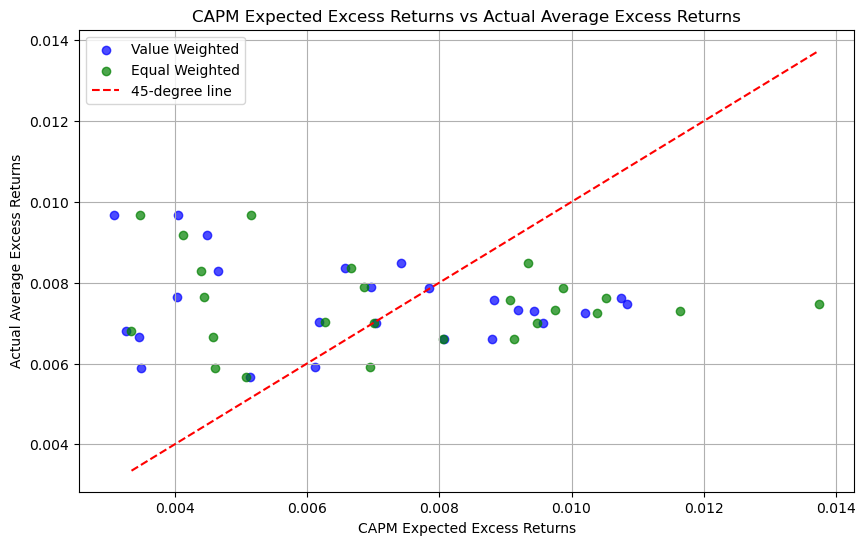

In [67]:
# Plotting CAPM Expected Excess Returns vs Actual Average Excess Returns

# Value Weighted 
plt.figure(figsize=(10, 6))

plt.scatter(average_df_port_vw_excess, capm_excess_returns, alpha=0.7, color='blue') # Plotting Portfolios with CAPM vs Value Weighted Actual Returns
plt.scatter(average_df_port_ew_excess, capm_excess_returns, alpha=0.7, color='green') # Plotting Portfolios with CAPM vs Equal Weighted Actual Returns
plt.plot([average_df_port_ew_excess.min(), average_df_port_ew_excess.max()],
         [average_df_port_ew_excess.min(), average_df_port_ew_excess.max()],
         color='red', linestyle='--')

plt.title('CAPM Expected Excess Returns vs Actual Average Excess Returns')
plt.xlabel('CAPM Expected Excess Returns')
plt.ylabel('Actual Average Excess Returns')
plt.legend([ 'Value Weighted', 'Equal Weighted', '45-degree line'])
plt.grid()
plt.show()


In [68]:
# Finding best to worst performing portfolios (Value Weighted)

# Ensuring index alignment --> IZZY WOULD PREFER IF THEY ALL HAD THE SAME ACTUAL LABELS, BUT IS SCARED IT WOULD AFFECT THE CODE TO MAKE THE SCATTER PLOT
capm_excess_returns.index = average_df_port_vw_excess.index

# Calculate the 'Pricing Error' (Alpha)
print("Sample of CAPM Value Weighted Errors (not in order):")
capm_vw_errors = abs(average_df_port_vw_excess - capm_excess_returns)
print(capm_vw_errors.head())

# Sort them to see which ones have the smallest error
print("Value Weighted Portfolios where CAPM works best (Smallest Errors):")
print(capm_vw_errors.sort_values().head())

# Sort them to see which ones have the largest error
print("Value Weighted Portfolios where CAPM works worst (Largest Errors):")
print(capm_vw_errors.sort_values(ascending=False).head())

Sample of CAPM Value Weighted Errors (not in order):
SMALL LoBM    0.006579
ME1 BM2       0.001054
ME1 BM3       0.000018
ME1 BM4       0.002134
SMALL HiBM    0.003365
dtype: float64
Value Weighted Portfolios where CAPM works best (Smallest Errors):
ME1 BM3     0.000018
ME3 BM3     0.000041
BIG HiBM    0.000222
ME5 BM4     0.000522
ME4 BM3     0.000840
dtype: float64
Value Weighted Portfolios where CAPM works worst (Largest Errors):
SMALL LoBM    0.006579
ME2 BM1       0.005638
ME3 BM1       0.004688
ME4 BM1       0.003640
ME4 BM2       0.003619
dtype: float64


In [69]:
# Finding best to worst performing portfolios (Equal Weighted)

# Ensuring index alignment --> IZZY WOULD PREFER IF THEY ALL HAD THE SAME ACTUAL LABELS, BUT IS SCARED IT WOULD AFFECT THE CODE TO MAKE THE SCATTER PLOT
capm_excess_returns.index = average_df_port_ew_excess.index

# Calculate the 'Pricing Error' (Alpha)
capm_ew_errors = abs(average_df_port_ew_excess - capm_excess_returns)
print("Sample of CAPM Equal Weighted Errors (not in order):")
print(capm_ew_errors.head())

# Sort them to see which ones have the smallest error
print("Equal Weighted Portfolios where CAPM works best (Smallest Errors):")
print(capm_ew_errors.sort_values().head())

# Sort them to see which ones have the largest error
print("Equal Weighted Portfolios where CAPM works worst (Largest Errors):")
print(capm_ew_errors.sort_values(ascending=False).head())

Sample of CAPM Equal Weighted Errors (not in order):
SMALL LoBM    0.004516
ME1 BM2       0.000856
ME1 BM3       0.002012
ME1 BM4       0.004330
SMALL HiBM    0.006260
dtype: float64
Equal Weighted Portfolios where CAPM works best (Smallest Errors):
ME3 BM3    0.000009
ME5 BM4    0.000587
ME4 BM3    0.000744
ME1 BM2    0.000856
ME3 BM2    0.001022
dtype: float64
Equal Weighted Portfolios where CAPM works worst (Largest Errors):
SMALL HiBM    0.006260
ME2 BM1       0.006211
ME3 BM1       0.005050
SMALL LoBM    0.004516
ME1 BM4       0.004330
dtype: float64
